In [1]:
from sklearn.datasets import make_moons
X,y = make_moons(n_samples=1000, noise=0.05)

In [8]:
X

array([[ 0.49199817,  0.8908729 ],
       [ 0.03083099,  0.25238513],
       [ 0.57773263,  0.68070827],
       ...,
       [ 2.01794763,  0.40639858],
       [ 1.4584816 , -0.49011297],
       [ 1.43536952, -0.30655146]], shape=(1000, 2))

In [2]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps = 0.05, min_samples=5)
dbscan.fit(X)

,eps,0.05
,min_samples,5
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


In [4]:
len(dbscan.labels_)

1000

In [5]:
dbscan.labels_

array([ 0,  1, -1,  0,  2,  0, -1,  3,  4,  4,  6,  2, -1,  2,  1,  5,  5,
        6,  0,  7,  5,  4,  8,  3,  3,  7,  0,  4,  0,  3,  2,  7,  2,  8,
        7,  4,  0,  2,  2, -1,  0,  7,  1,  6,  2,  7,  7,  0,  2,  2,  5,
        4,  8,  5,  4,  1,  4,  2,  3,  2,  7,  4,  4,  8,  4,  4,  4,  2,
        1,  9,  7,  7,  7,  5,  0, 10,  8,  4,  3,  8,  0, -1,  1,  0,  6,
        4,  5,  7,  6,  0,  5,  7,  2,  0,  5,  5,  0,  9,  7,  4,  6,  0,
        7,  4,  3,  4,  1,  5,  4,  5, -1,  7,  4,  4,  3,  7,  5,  3,  5,
        3,  1,  3,  5,  0,  7,  2,  4,  4,  5,  8,  6,  0,  5,  3,  5,  2,
        0,  7,  0,  4,  7,  4,  4,  7,  1,  2,  2,  4,  2,  7,  8,  5, -1,
        4,  7,  2,  0,  5,  0,  4, -1,  5,  7,  7,  3,  7,  6,  4,  4,  4,
        7,  4,  3,  4,  0,  8,  1,  0,  2,  5, -1,  7,  4,  0, -1,  2,  7,
        4, -1,  8,  3,  4,  7,  1,  2,  1,  4,  0,  4,  4,  3,  0,  3,  5,
        4,  3, -1,  7,  0,  7,  4,  7,  3,  0,  4,  0,  4, -1,  7,  5,  4,
        7,  2,  3, -1,  0

Text(0, 0.5, 'X [1]')

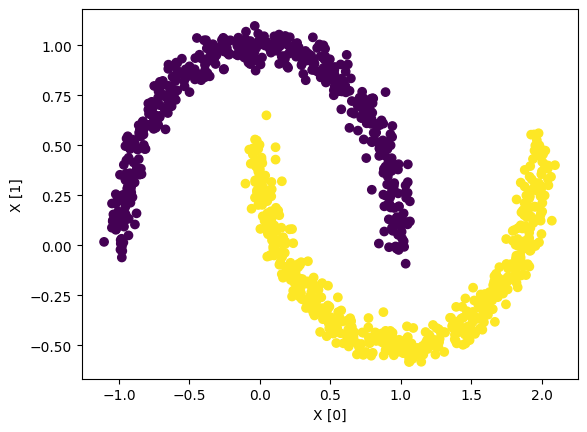

In [13]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0], X[:,1], c=y)
plt.xlabel("X [0]")
plt.ylabel("X [1]")

In [6]:
X[0]

array([0.49199817, 0.8908729 ])

-1 means algorithm marked it as anomaly

In [18]:
len(dbscan.core_sample_indices_) == len(set(dbscan.labels_))

False

In [19]:
len(dbscan.core_sample_indices_)

818

In [22]:
len(set(dbscan.labels_))

12

In [ ]:
dbscan.components_

array([[ 0.49199817,  0.8908729 ],
       [ 0.03083099,  0.25238513],
       [-0.04671213,  0.96458076],
       ...,
       [ 1.70490313, -0.17374994],
       [ 1.39574462, -0.38815303],
       [ 2.01794763,  0.40639858]], shape=(818, 2))

In [27]:
len(dbscan.core_sample_indices_) == len(dbscan.components_)

True

It does not have any predict method because we use other algorithms to predict on new instance 


In [28]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=50)
knn.fit(dbscan.components_, dbscan.labels_[dbscan.core_sample_indices_])

,n_neighbors,50
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [29]:
import numpy as np
knn.predict(np.array([[-0.5, 0], [0, 0.5], [1, -0.1], [2, 1]]))

array([4, 1, 5, 7])